In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, cross_validate, StratifiedKFold, LeaveOneOut
from sklearn.neighbors import KNeighborsRegressor, KNeighborsClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, accuracy_score, zero_one_loss
from sklearn.datasets import load_iris

## Custo computacional + Custo KNN

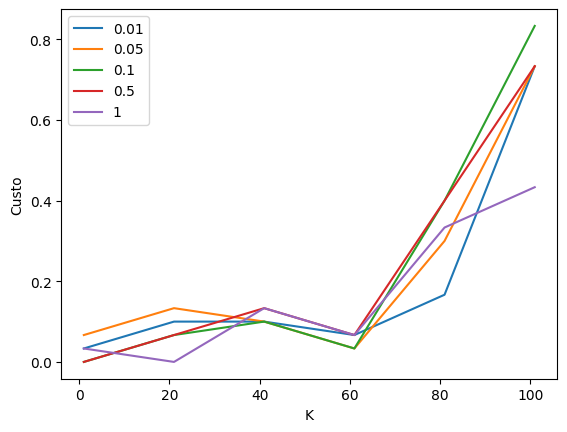

In [9]:
TRAIN_SIZE = 0.8
LAMBDAS = [0.01, 0.05, 0.1, 0.5, 1]
ks = [i for i in range(1, int(TRAIN_SIZE * 150), 20)]

iris = load_iris()

for lambda_ in LAMBDAS:
  zol_list = []
  for k in ks:
    train_f, test_f, train_t, test_t = train_test_split(iris.data, iris.target, train_size=TRAIN_SIZE)
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(train_f, train_t)
    predicted = knn.predict(test_f)

    zol = zero_one_loss(predicted, test_t)
    custo = zol + lambda_ * 1 / k
    zol_list.append(zol)

  plt.plot(ks, zol_list, label=str(lambda_))

plt.legend()
plt.xlabel('K')
plt.ylabel('Custo')
plt.show()

## Validação cruzada

**model_selection.cross_val_score()** -> Retorna apenas a acurácia do modelo

In [10]:
iris = load_iris()
data = iris.data
target = iris.target

knn = KNeighborsClassifier()
results = cross_val_score(
    knn,
    data,
    target,
    cv=10
)

results.mean()

np.float64(0.9666666666666668)

**model_selection.cross_validate()** -> Retorna, além da acurácia do modelo, informações como custo computacional, tempo de execução entre outras informaçoes.

In [11]:
results = cross_validate(
    knn,
    data,
    target,
    cv=5,
    return_train_score=True
)
results

# fit_time = quanto de tempo que o knn demorou para treinar com os dados de do dataset
# score_time = quanto de tempo que o knn demorou para avaliar os dados de do dataset
# test_score = resultados das previsõs para o conjunto de teste
# train_score = resultados das previsõs para o conjunto de treino

{'fit_time': array([0.00160503, 0.00265241, 0.00145054, 0.0015614 , 0.00202918]),
 'score_time': array([0.00366116, 0.00404286, 0.00349522, 0.00377584, 0.0043118 ]),
 'test_score': array([0.96666667, 1.        , 0.93333333, 0.96666667, 1.        ]),
 'train_score': array([0.96666667, 0.96666667, 0.975     , 0.975     , 0.96666667])}

## Validação cruzada estratificada
(com as classes balanceadas em cada fold)

In [12]:
knn = KNeighborsClassifier()
stratifiedKFold = StratifiedKFold(n_splits=5, shuffle=True)

results = cross_validate(
    knn,
    data,
    target,
    cv=stratifiedKFold
)
results

{'fit_time': array([0.00227928, 0.00236106, 0.00175619, 0.00150204, 0.00167608]),
 'score_time': array([0.00708938, 0.00690937, 0.00377822, 0.00408387, 0.00347829]),
 'test_score': array([0.93333333, 0.9       , 0.96666667, 1.        , 0.96666667])}

## Validação cruzada Leave-One-Out
(um fold para cada valor item no df)

In [14]:
knn = KNeighborsClassifier()
loo = LeaveOneOut()

results = cross_validate(
    knn,
    data,
    target,
    cv=loo
)
results

{'fit_time': array([0.0044415 , 0.00148034, 0.00140047, 0.00160122, 0.00144911,
        0.00326324, 0.00164318, 0.00179982, 0.00206733, 0.00173712,
        0.00197411, 0.00231647, 0.00151515, 0.00258875, 0.00170732,
        0.00194621, 0.00174165, 0.00152516, 0.00156021, 0.00152946,
        0.0020926 , 0.00244331, 0.0018878 , 0.00200987, 0.00165105,
        0.00209737, 0.00238204, 0.00166821, 0.00148225, 0.00159979,
        0.00154352, 0.00157332, 0.00152493, 0.00323629, 0.00551033,
        0.00171995, 0.0039959 , 0.00455427, 0.00161147, 0.00259233,
        0.0042069 , 0.00261807, 0.00251222, 0.00222898, 0.00252628,
        0.00161862, 0.00246453, 0.00285625, 0.0016067 , 0.00290036,
        0.0042696 , 0.00412893, 0.00283861, 0.00232005, 0.00145268,
        0.00203013, 0.00166392, 0.00158548, 0.00161219, 0.00153828,
        0.00208855, 0.00163221, 0.00159717, 0.00168705, 0.00159645,
        0.00161028, 0.00532246, 0.00180459, 0.00156498, 0.00169873,
        0.00167465, 0.00164247, 0.00